This notebook produces Figures 15 and S2, which are histograms of displacement rates 
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [1]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
%matplotlib  widget

In [2]:
#define dimensions of each SLC
x1 = 0; y1= 0    #values are 0 if interferogram has already been cropped
dx= 9000; dy=1575  

#define aspect ratio for plotting
aspect_rat = (21.8/dy) / (34.44/dx)

# make a conversion factor from radians to cm. 
wavelength = 5.5465763 # C-band, in cm 
rad2cm = wavelength/(4*np.pi) 

In [3]:
# load average coherence (average gamma1 and average gamma2)
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

#calculate differences between method 1 and method 2
capped_m2 = np.where(coh_avg_m2 > 0.8475, 0.8475, coh_avg_m2)
diff_avg = coh_avg_m1 - capped_m2
diff = coh_avg_m1 - coh_avg_m2

In [10]:
# Load in rate maps - convert them to cm/yr at the same time! 

# Unweighted
file = '../../2.1_Inverting_for_displacement_rates/unweighted_rate_map.r4'   
f1 = gdal.Open(file, gdal.GA_ReadOnly)
unw_rates = f1.ReadAsArray()*rad2cm; f1 = None
print('Unweighted rates loaded.')

# Weighted with method 1 (complex coherence magnitude)
file = '../../2.1_Inverting_for_displacement_rates/coh_1_weighted_rate_map.r4'  
f1 = gdal.Open(file, gdal.GA_ReadOnly)
coh1_w_rates = f1.ReadAsArray()*rad2cm; f1 = None
print('Weighted rates with method 1 loaded.')

# Weighted with method 2 (unit vector coherence magnitude)
file = '../../2.1_Inverting_for_displacement_rates/coh_2_weighted_rate_map.r4'  
f1 = gdal.Open(file, gdal.GA_ReadOnly)
coh2_w_rates = f1.ReadAsArray()*rad2cm; f1 = None
print('Weighted rates with unit vector coherence (method 2) loaded.')

Unweighted rates loaded.
Weighted rates with method 1 loaded.
Weighted rates with unit vector coherence (method 2) loaded.


In [13]:
# Mask the rates to plot and make sure they are in the correct locations and the masking makes sense.
unw_rate_masked_coh1 = np.where(coh_avg_m1 >= 0.1,unw_rates,np.nan)

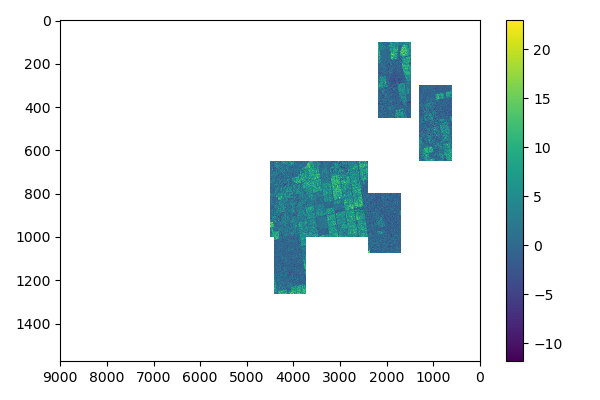

In [14]:
plt.figure(figsize=(6,4),tight_layout=True)
plt.imshow(unw_rate_masked_coh1,aspect='auto',interpolation='none')
plt.xlim(dx,0)
plt.colorbar()
plt.show()

In [15]:
# Plotting histograms of rates with the three methods using the same set of pixels. 

# Pull out only the relevant pixels
# Use the condition: gamma1(method1)>0.75 to generate the mask 
unw_rate_masked_coh1_ss = np.where(coh_avg_m1 >= 0.75,unw_rates,np.nan)
unw_rate_masked_coh2_ss = np.where(coh_avg_m1 >= 0.75,unw_rates,np.nan)

# making sure Nans don't accidentally plot in the hists
coh1_w_masked_ss = np.where(coh_avg_m1 >= 0.75,coh1_w_rates,np.nan)
coh2_w_masked_ss = np.where(coh_avg_m1 >= 0.75,coh2_w_rates,np.nan)

# turn into 1D array for histogram
unw_rate_masked_coh1_1D_ss = unw_rate_masked_coh1_ss[~np.isnan(unw_rate_masked_coh1_ss)].flatten()
unw_rate_masked_coh2_1D_ss = unw_rate_masked_coh2_ss[~np.isnan(unw_rate_masked_coh2_ss)].flatten()

# flatten the arrays so they can be used in the histograms below
coh1_w_masked_1D_ss = coh1_w_masked_ss.flatten()
coh3_w_masked_1D_ss = coh2_w_masked_ss.flatten()

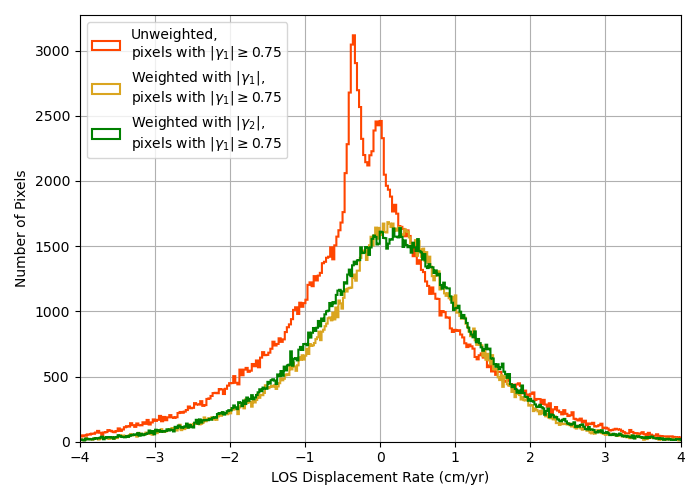

In [ ]:
# plot it. This is Figure 15.
fig,ax = plt.subplots(1,1,figsize=(7,5),tight_layout=True)  
numBins = 750
ax.hist(unw_rate_masked_coh1_1D_ss,bins=numBins,label = 'Unweighted,\npixels with $|\gamma_{1}|\geq$0.75',histtype='step',color='orangered',linewidth=1.5)
ax.hist(coh1_w_masked_1D_ss,bins=numBins,label = 'Weighted with |$\gamma_{1}|$,\npixels with $|\gamma_{1}|\geq$0.75',histtype='step',color='goldenrod',linewidth=1.5)
ax.hist(coh3_w_masked_1D_ss,bins=numBins, label = 'Weighted with |$\gamma_{2}|$,\npixels with $|\gamma_{1}|\geq$0.75',histtype='step',color='green',linewidth=1.5)
ax.legend(loc='upper left')
ax.set_xlabel('LOS Displacement Rate (cm/yr)')
ax.set_ylabel('Number of Pixels')  
ax.set_xlim(-4,4); ax.grid()
plt.show()
# plt.savefig('hists_rates_all_focus_areas_same_set_of_pixels.png',transparent=True,bbox_inches='tight',dpi=500)

In [18]:
# Define the Focus area bounds 
imperial_road = [6820, 100, 7520, 450]  
transect_roads = [4500, 650, 6600, 1000]    
ElCentro_airport = [4575, 980, 5275,1265]
pools = [7700,300, 8400, 650]    
imperial_airport = [6600,800,7300,1075] 

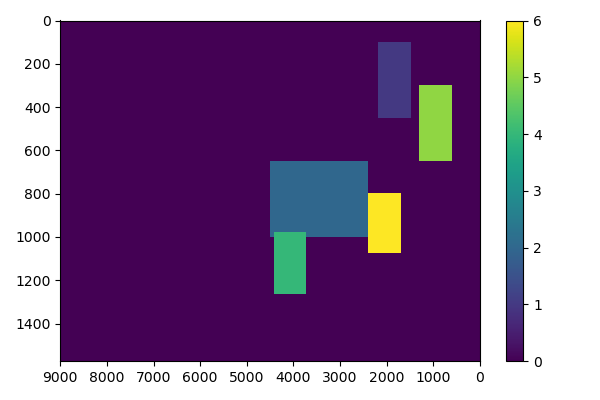

In [22]:
# Make a mask where the only nonzero values are where the focus areas are located
box_mask = np.zeros((dy,dx),dtype=float)

for y in range(dy):
    for x in range(dx):
        if x>=imperial_road[0] and x<=imperial_road[2] and y<=imperial_road[3] and y>=imperial_road[1]:
            box_mask[y,x] = 1
        if x>=transect_roads[0] and x<=transect_roads[2] and y<=transect_roads[3] and y>=transect_roads[1]:
            box_mask[y,x] = 2
        if x>=ElCentro_airport[0] and x<=ElCentro_airport[2] and y<=ElCentro_airport[3] and y>=ElCentro_airport[1]:
            box_mask[y,x] = 4
        if x>=pools[0] and x<=pools[2] and y<=pools[3] and y>=pools[1]:
            box_mask[y,x] = 5
        if x>=imperial_airport[0] and x<=imperial_airport[2] and y<=imperial_airport[3] and y>=imperial_airport[1]:
            box_mask[y,x] = 6

#need to flip box_mask left-right (currently have pixel coordinates saved for plotting not actual array coordinates)
box_mask = np.fliplr(box_mask)

plt.figure(figsize=(6,4),tight_layout=True)
plt.imshow(box_mask,aspect='auto',interpolation='none')
plt.xlim(dx,0)
plt.colorbar()
plt.show()

In [25]:
# make a function for grabbing the correct histogram data for each focus area: 
def grab_focus_area(focus_area):
    #select zoom in
    zoom_in_select = focus_area
    #generate the mask for each zoom in:
    m1_wr_avg_masked = np.where(box_mask == zoom_in_select,coh1_w_rates,np.nan)
    m3_wr_avg_masked = np.where(box_mask == zoom_in_select,coh2_w_rates,np.nan)
    uw_avg_masked = np.where(box_mask == zoom_in_select,unw_rates,np.nan)
    #turn into 1D array for histogram
    m1_wr_mask_1D = m1_wr_avg_masked.flatten()
    m3_wr_mask_1D = m3_wr_avg_masked.flatten()
    uw_mask_1D = uw_avg_masked.flatten()
    return m1_wr_mask_1D, m3_wr_mask_1D,uw_mask_1D

In [ ]:
# now run the function on each focus area to grab the rates from just the focus area called.
A_m1, A_m3, A_uw = grab_focus_area(1)
B_m1, B_m3, B_uw = grab_focus_area(5)
C_m1, C_m3, C_uw = grab_focus_area(2)
D_m1, D_m3, D_uw = grab_focus_area(6)
E_m1, E_m3, E_uw = grab_focus_area(4)

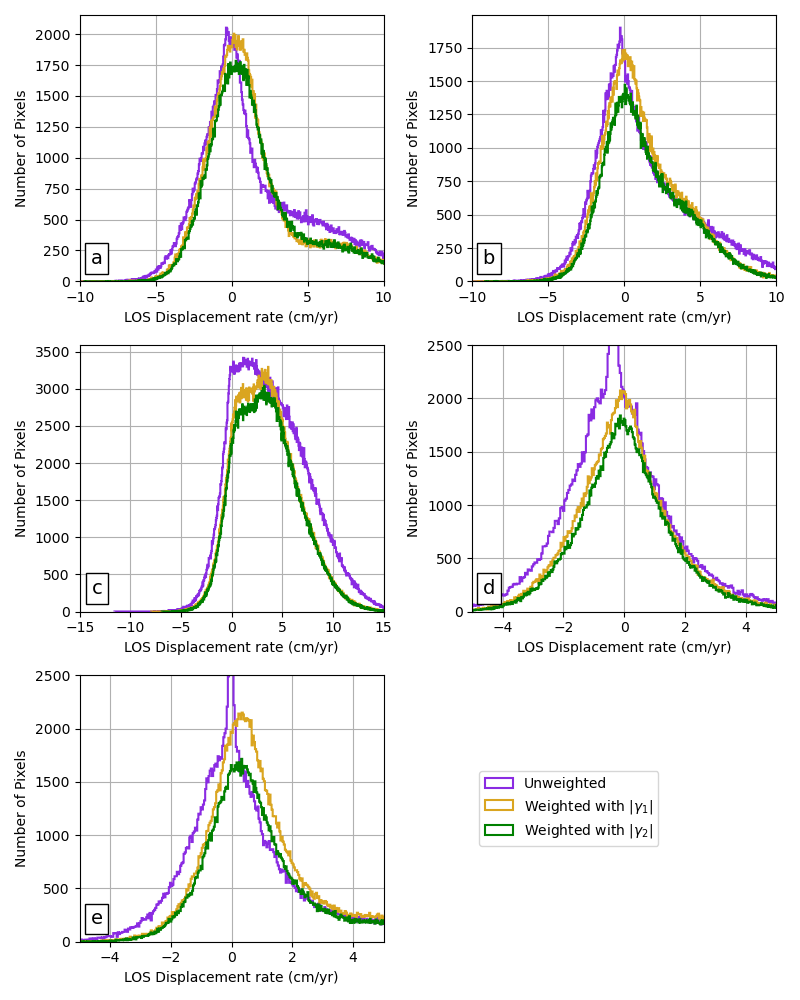

In [ ]:
# Now plot them all. This is Figure S2.

label_x = 0.075
label_y = 0.05
props = dict(boxstyle='square',facecolor='white',edgecolor='black')

fig, axs = plt.subplots(3,2,figsize=(8,10),tight_layout=True)
ax = axs[0,0]
ax.hist(A_uw,bins=numBins,label='Unweighted',histtype='step',color='blueviolet',linewidth=1.5)
ax.hist(A_m1,bins=numBins,label='Weighted with |$\gamma_{1}|$',histtype='step',color='goldenrod',linewidth=1.5)
ax.hist(A_m3,bins=numBins,label='Weighted with |$\gamma_{2}|$',histtype='step',color='green',linewidth=1.5)
#ax.legend(loc='upper left')
ax.set_xlim(-10,10)
ax.set_ylabel('Number of Pixels')
ax.set_xlabel('LOS Displacement rate (cm/yr)')
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.grid()

ax = axs[0,1]
ax.hist(B_uw,bins=numBins,label='Unweighted',histtype='step',color='blueviolet',linewidth=1.5)
ax.hist(B_m1,bins=numBins,label='Weighted with |$\gamma_{1}|$',histtype='step',color='goldenrod',linewidth=1.5)
ax.hist(B_m3,bins=numBins,label='Weighted with |$\gamma_{2}|$',histtype='step',color='green',linewidth=1.5)
ax.set_xlim(-10,10)
ax.set_ylabel('Number of Pixels')
ax.set_xlabel('LOS Displacement rate (cm/yr)')
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.grid() 

ax = axs[1,0]
ax.hist(C_uw,bins=numBins,label='Unweighted',histtype='step',color='blueviolet',linewidth=1.5)
ax.hist(C_m1,bins=numBins,label='Weighted with |$\gamma_{1}|$',histtype='step',color='goldenrod',linewidth=1.5)
ax.hist(C_m3,bins=numBins,label='Weighted with |$\gamma_{2}|$',histtype='step',color='green',linewidth=1.5)
ax.set_xlim(-15,15)
ax.set_ylabel('Number of Pixels')
ax.set_xlabel('LOS Displacement rate (cm/yr)')
ax.text(label_x, label_y, 'c', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.grid() 

ax = axs[1,1]
ax.hist(D_uw,bins=numBins,label='Unweighted',histtype='step',color='blueviolet',linewidth=1.5)
ax.hist(D_m1,bins=numBins,label='Weighted with |$\gamma_{1}|$',histtype='step',color='goldenrod',linewidth=1.5)
ax.hist(D_m3,bins=numBins,label='Weighted with |$\gamma_{2}|$',histtype='step',color='green',linewidth=1.5)
ax.set_xlim(-5,5)
ax.set_ylim(0,2500)
ax.set_ylabel('Number of Pixels')
ax.set_xlabel('LOS Displacement rate (cm/yr)')
ax.text(label_x, label_y, 'd', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.grid() 

ax = axs[2,0]
w1 = ax.hist(E_uw,bins=numBins,label='Unweighted',histtype='step',color='blueviolet',linewidth=1.5)
w2 = ax.hist(E_m1,bins=numBins,label='Weighted with |$\gamma_{1}|$',histtype='step',color='goldenrod',linewidth=1.5)
uw = ax.hist(E_m3,bins=numBins,label='Weighted with |$\gamma_{2}|$',histtype='step',color='green',linewidth=1.5)
ax.set_xlim(-5,5)
ax.set_ylim(0,2500)
ax.set_ylabel('Number of Pixels')
ax.set_xlabel('LOS Displacement rate (cm/yr)')
ax.text(label_x, label_y, 'e', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.grid() 

ax1 = axs[2,1]
ax1.axis('off')
handles, labels = ax.get_legend_handles_labels()
ax1.legend(handles, labels, loc='center left')

plt.show()
# plt.savefig('hists_focus_areas.png',transparent=True,bbox_inches='tight',dpi=500)